# aimio-py Examples

- **By:** [Erica Baldesarra, Johannes Bereiter-Payr](linkedin.com/in/erica-baldesarra-68966123a), 2026  
- **License:** CC-BY 
- **How to cite:** Cite the ORMIR_XCT publication: *Kuczynski et al., (2024). ORMIR_XCT: A Python package for high resolution peripheral quantitative computed tomography image processing. Journal of Open Source Software, 9(97), 6084, https://doi.org/10.21105/joss.06084*

---
# Aims

- This Jupyter Notebook provides an example of reading, writing, and viewing metadata of Scanco proprietary image types (i.e. AIM and ISQ)

  **Table of contents**  
  [Step 1: Importing](#importing)   
  [Step 2: Reading](#reading)  
  [Step 3: Writing](#)  
  [Step 4: Viewing Metadata](#metadata)  
  [Step 5: Working with Processing Logs](#proclogs)


<a name="importing"></a>
## *Step 1: Importing*

Set up imports and file paths

In [1]:
from zenodo_get import download

from os import listdir
from os.path import join
from pathlib import Path

from py_aimio import read_aim, write_aim, log_to_dict, dict_to_log
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Specify the directory path
directory_path = Path(join('images', 'AIMIO_Examples'))

In [7]:
download(doi="10.5281/zenodo.21284559", output_dir=directory_path)

2026-07-09 13:42:50.058 | INFO     | zenodo_get.zget:_zenodo_download_logic:328 - Output directory: /home/jpunkt/Documents/Projekte/2026/ORMIR-Workshop/ORMIR-XCT/examples/images/AIMIO_Examples
2026-07-09 13:42:51.810 | INFO     | zenodo_get.zget:_zenodo_download_logic:426 - Title: HR-pQCT *.AIM file examples
2026-07-09 13:42:51.812 | INFO     | zenodo_get.zget:_zenodo_download_logic:438 - Total size: 39.7 MB
2026-07-09 13:42:51.813 | INFO     | zenodo_get.zget:_zenodo_download_logic:439 - Number of files: 8
Files:   0%|          | 0/8 [00:00<?, ?file/s]2026-07-09 13:42:51.853 | INFO     | zenodo_get.zget:_handle_single_file_download:203 - CHAR_NOCMP_030.AIM is already downloaded correctly.
2026-07-09 13:42:51.854 | INFO     | zenodo_get.zget:_handle_single_file_download:203 - CHAR_CHARCMP_020.AIM is already downloaded correctly.
2026-07-09 13:42:51.858 | INFO     | zenodo_get.zget:_handle_single_file_download:203 - CHAR_NOCMP_020.AIM is already downloaded correctly.
2026-07-09 13:42:51

In [8]:
files = [directory_path / f for f in listdir(directory_path) if f.endswith('.AIM')]

<a name="reading"></a>
## *Step 2: Reading*

Read example `*.aim` files and show the contents.

In [ ]:
def create_orthogonal_views(arr, spacing=10):
    center = [x // 2 for x in arr.shape]

    xy = arr[center[0], ...]
    xz = arr[:, center[1], :]
    yz = arr[..., center[2]]

    y_spacer = np.zeros((xy.shape[0], spacing))
    topview = np.concat([xy, y_spacer, yz.transpose(1, 0)], axis=1)

    x_spacer = np.zeros((spacing, topview.shape[1]))
    botview = np.concat([xz, np.zeros((xz.shape[0], topview.shape[1] - xz.shape[1]))], axis=1)

    return np.concat([topview, x_spacer, botview], axis=0)


Plot the example images

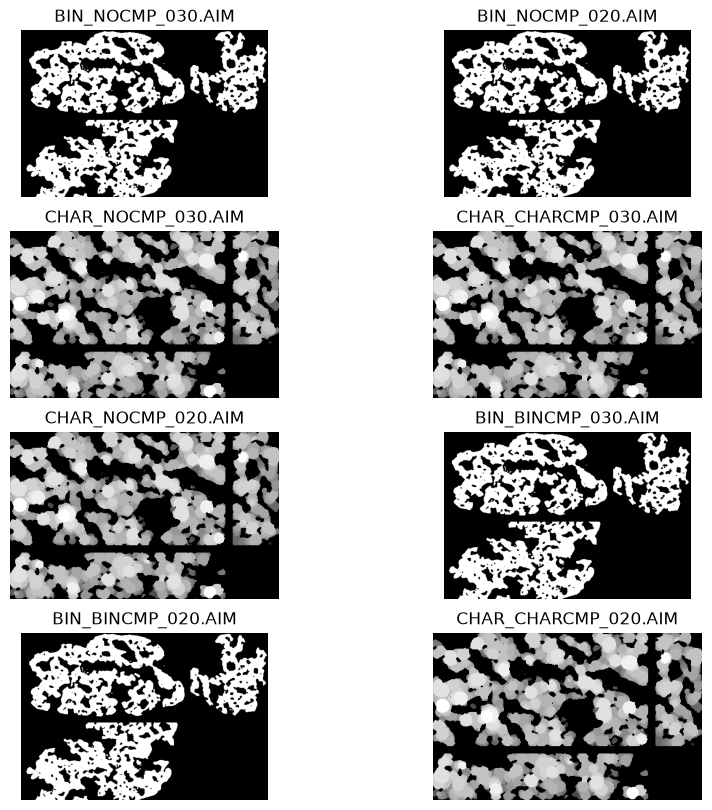

In [ ]:
nrows, ncols = 4, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(10, 10))

for i, file in enumerate(files):
    arr, _ = read_aim(str(file))
    
    ax[i // ncols, i % ncols].imshow(create_orthogonal_views(arr), cmap='gray')
    ax[i // ncols, i % ncols].set_title(f"{file.name}")
    ax[i // ncols, i % ncols].axis('off')

<a name='metadata'></a>
## *Step 4: Viewing Metadata*

How to view the metadata of the AIM files. The metadata is stored in a dictionary format, which can be accessed and updated. Convenience functions for conversion from and to a string based format can be used for printing.

In [4]:
_, meta = read_aim(str(files[0]))

type(meta)

dict

In [5]:
logstring = dict_to_log(meta)
print(logstring)

! Processing Log
!
!-------------------------------------------------------------------------------
filename                      images/AIMIO_Examples/BIN_NOCMP_030.AIM           
version                                             3
id                                                  0
reference                                           0
aim_type                                        65537
buffer_type                                         1
position                             351        296         37
dimensions                           400        208        188
offset                                 0          0          0
element_size                  0.019999999552965164 0.019999999552965164 0.019999999552965164
processing_log                {'Created by': 'ISQ_TO_AIM (IPL)', 'Time': '18-AUG-2005 19:50:22.01', 'Original file': 'DK0:[MICROCT.DATA.00002768.00004172]C0004158.ISQ', 'Patient Name': 'Berkeley Advance Biomaterials; BO gran', 'Index Patient': 2768, 'Index Measuremen

<a name="proclogs"></a>
## *Step 5: Working with Processing Logs*

Parameters can be added to the processing log by manipulating the dict.

In [10]:
meta['my processing step'] = 'This is a test entry'

In [11]:
print(dict_to_log(meta))

! Processing Log
!
!-------------------------------------------------------------------------------
filename                      images/AIMIO_Examples/BIN_NOCMP_030.AIM           
version                                             3
id                                                  0
reference                                           0
aim_type                                        65537
buffer_type                                         1
position                             351        296         37
dimensions                           400        208        188
offset                                 0          0          0
element_size                  0.019999999552965164 0.019999999552965164 0.019999999552965164
processing_log                {'Created by': 'ISQ_TO_AIM (IPL)', 'Time': '18-AUG-2005 19:50:22.01', 'Original file': 'DK0:[MICROCT.DATA.00002768.00004172]C0004158.ISQ', 'Patient Name': 'Berkeley Advance Biomaterials; BO gran', 'Index Patient': 2768, 'Index Measuremen